In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.feature_extraction.text import HashingVectorizer
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/spam.csv', encoding='latin_1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df.rename(columns={'v2': 'MESSAGE', 'v1': 'Spam'})
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df['Spam'] = LabelEncoder().fit_transform(df['Spam'])

In [6]:
print(df.head())

   Spam                                            MESSAGE
0     0  Go until jurong point, crazy.. Available only ...
1     0                      Ok lar... Joking wif u oni...
2     1  Free entry in 2 a wkly comp to win FA Cup fina...
3     0  U dun say so early hor... U c already then say...
4     0  Nah I don't think he goes to usf, he lives aro...


In [7]:
df['Spam'].value_counts()

,count
Spam,
0,4825
1,747


In [8]:
X = df['MESSAGE']
y = df['Spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape

((3900,), (1672,))

Preprocessing

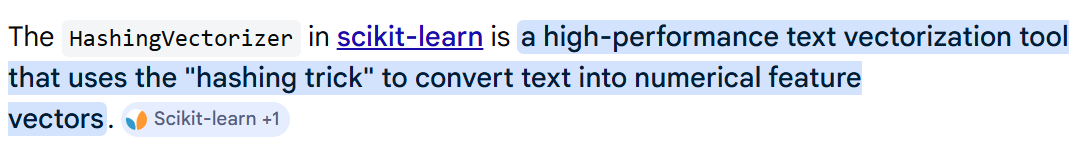

In [9]:
# Text turdagi datalarimizni raqamli ko'rinishga convert qilish

hashing = HashingVectorizer(n_features=1000, stop_words="english")
X_train = hashing.fit_transform(X_train)
X_test = hashing.fit_transform(X_test)

Creating and training Classification models

**BernouliNB classifier**

1. Cross_val_score of BernoulliNB: [0.96076923 0.96076923 0.94615385]

2. Std of Cross_val_scores of bnb classifier: 0.0068897583807920396

3. Classification report of BNB model: 
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1453
           1       0.89      0.82      0.85       219

    accuracy                           0.96      1672
   macro avg       0.93      0.90      0.92      1672
weighted avg       0.96      0.96      0.96      1672

Precision: 0.8905472636815921
Recall: 0.817351598173516
F1_score: 0.8523809523809525


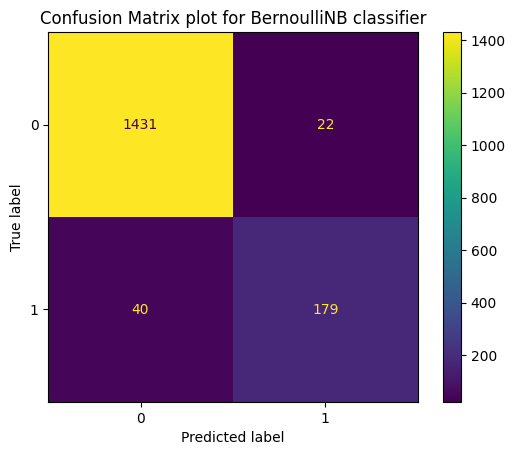

In [38]:
# BernouliNB classifier
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_predict1 = bnb.predict(X_test)

# Cross_val_scores
cross_val_score_bnb = cross_val_score(bnb, X_train, y_train, cv=3, scoring="accuracy")
print(f"1. Cross_val_score of BernoulliNB: {cross_val_score_bnb}\n")


print(f'2. Std of Cross_val_scores of bnb classifier: {np.std(cross_val_score_bnb)}\n') # Low std ---> stable model

# Classification report
print(f"3. Classification report of BNB model: \n{classification_report(y_test, y_predict1)}")

# F1_sore, Precision and Recall


precision = cms_bnb[1, 1]/(cms_bnb[1, 1] + cms_bnb[0, 1]) # precision = TP/(TP+FP)
print(f"Precision: {precision}")

recall = cms_bnb[1, 1]/(cms_bnb[1, 0]+cms_bnb[1, 1]) # Recall = TP/(TP+FN)
print(f"Recall: {recall}")

f1_sore = 2*(precision*recall)/(precision+recall)
print(f"F1_score: {f1_sore}")


# Confusion Matrix
cms_bnb = confusion_matrix(y_test, y_predict1, labels=bnb.classes_)
disp = ConfusionMatrixDisplay(cms_bnb, display_labels=bnb.classes_)
disp.plot()
plt.title(f"Confusion Matrix plot for BernoulliNB classifier")
plt.show()


**Stochastic gradient decent (SGDClassifier)**

1. Cross_val_score of SGDClassifier model: [0.97435897 0.97307692 0.96666667 0.96538462 0.96538462]

Std of Cross_val_scores of SGDClassifier classifier: 0.0039223227027636665

3. Classification report of SGDClassifier model: 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1453
           1       0.93      0.80      0.86       219

    accuracy                           0.97      1672
   macro avg       0.95      0.90      0.92      1672
weighted avg       0.97      0.97      0.96      1672



Text(0.5, 1.0, 'Confusion Matrix plot for SGDClassifier')

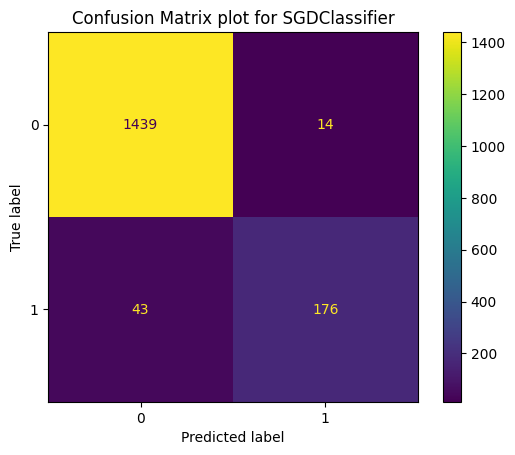

In [11]:
# SGDClassifier
from sklearn.linear_model import SGDClassifier
sgd_cls = SGDClassifier(random_state=42)
sgd_cls.fit(X_train, y_train)
y_predict2 = sgd_cls.predict(X_test)

# Cross_val_score
cross_val_score_sgd = cross_val_score(sgd_cls, X_train, y_train)
print(f"1. Cross_val_score of SGDClassifier model: {cross_val_score_sgd}\n")

# std of cross_val_scores
print(f'Std of Cross_val_scores of SGDClassifier classifier: {np.std(cross_val_score_sgd)}\n') # Low std ---> stable model

# Classification report
print(f"3. Classification report of SGDClassifier model: \n{classification_report(y_test, y_predict2)}")


# Confusion Matrix for sgd_Classifier
cms_sgdClassifier = confusion_matrix(y_test, y_predict2, labels=sgd_cls.classes_)
disp = ConfusionMatrixDisplay(cms_sgdClassifier, display_labels=sgd_cls.classes_)
disp.plot()
plt.title(f"Confusion Matrix plot for SGDClassifier")

**RandomForest Classifier**

1. Cross_val_score of RandomForest model: [0.97564103 0.96923077 0.96538462 0.96538462 0.95512821]

2. Std of Cross_val_scores of RandomForest classifier: 0.006666666666666643

3. Classification report of RandomForest: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1453
           1       0.97      0.79      0.87       219

    accuracy                           0.97      1672
   macro avg       0.97      0.89      0.93      1672
weighted avg       0.97      0.97      0.97      1672



Text(0.5, 1.0, 'Confusion Matrix plot for RandomForest Classifier')

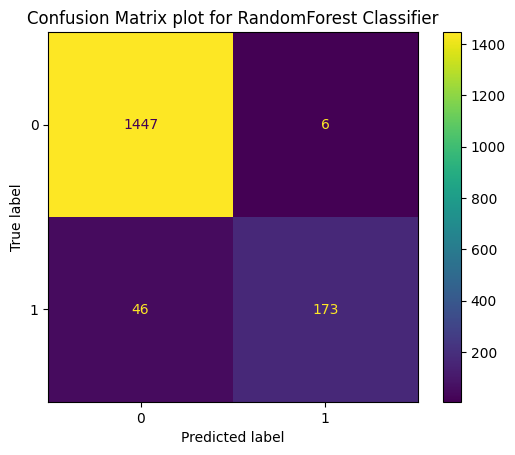

In [13]:
# RandomForest Classifier

from sklearn.ensemble import RandomForestClassifier
ran_for = RandomForestClassifier(random_state=42)
ran_for.fit(X_train, y_train)
y_predict3 = ran_for.predict(X_test)

# Cross_val_score
cross_val_score_ran_for = cross_val_score(ran_for, X_train, y_train)
print(f"1. Cross_val_score of RandomForest model: {cross_val_score_ran_for}\n")

# std of cross_val_scores
print(f'2. Std of Cross_val_scores of RandomForest classifier: {np.std(cross_val_score_ran_for)}\n') # Low std ---> stable model

# Classification report
print(f"3. Classification report of RandomForest: \n{classification_report(y_test, y_predict3)}")

# Confusion Matrix for RandomForst
cms_ran_for = confusion_matrix(y_test, y_predict3, labels=ran_for.classes_)
disp = ConfusionMatrixDisplay(cms_ran_for, display_labels = ran_for.classes_)
disp.plot()
plt.title(f"Confusion Matrix plot for RandomForest Classifier")